# VIP-SLAP2 all-modality data crunching notebook

This notebook is a deployment entry point for session-level preprocessing, QC, and event extraction across the VIP synaptic-dynamics dataset.

It handles:

- behavior / HARP / photodiode QC and imaging-epoch discovery
- glutamate SLAP2 QC and image/change/omission extraction
- calcium QC and extraction for paired red calcium channels
- voltage QC and event extraction for ASAP7- and ASAP8-class indicators

## Multi-epoch processing contract

Imaging epochs are treated as separate acquisitions on a common HARP clock. The processing code preserves imaging-off gaps, rejects event windows that cross a restart, and estimates calcium/voltage F0 independently within each epoch. For multi-epoch voltage sessions, first rerun the patched `extractDendrites.m` with `outputMode='trial'` or `'both'`; the notebook deliberately fails rather than silently reusing the first acquisition trace for later epochs.


In [1]:
# Notebook display + autoreload
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import json
import traceback
import warnings

import os
import tempfile

tmp = Path(r"D:\Temp\vip_slap2_tmp")
tmp.mkdir(parents=True, exist_ok=True)

os.environ["TEMP"] = str(tmp)
os.environ["TMP"] = str(tmp)
os.environ["TMPDIR"] = str(tmp)
tempfile.tempdir = str(tmp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

In [2]:
%matplotlib inline

## 1. Configure paths and processing switches

Adjust the path variables and `target_mice` list before running. The `RUN_*` switches let you rerun individual stages without editing the main loop.


In [3]:
# ---------------------------------------------------------------------
# Local repository / data paths
# ---------------------------------------------------------------------
# If running from inside the repo, this can usually stay as None.
# If imports fail, set REPO_ROOT to your local clone, e.g.
# REPO_ROOT = Path(r"C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis")
REPO_ROOT = None

if REPO_ROOT is not None:
    src_path = Path(REPO_ROOT) / "src"
    if str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))

BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")

# Optional local copy of the summary table. The registry discovers sessions from BASE_PATH;
# this file is only useful for ad hoc inspection or manual cross-checks.
SUMMARY_XLSX = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\VIP_SD_summary.xlsx")

# ---------------------------------------------------------------------
# Session selection
# ---------------------------------------------------------------------
target_mice = [
852835
]

EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]
PARADIGMS = ["change_detection_passive"]

# ---------------------------------------------------------------------
# Execution controls
# ---------------------------------------------------------------------
RUN_BEHAVIOR = True
# Set these to True only for modalities you want to regenerate.
# For voltage re-extraction after the epoch-aware MATLAB/Python updates, keep
# behavior + voltage enabled and leave glutamate/calcium disabled unless you
# intentionally want to recompute those products too.
RUN_GLUTAMATE_QC = False
RUN_GLUTAMATE_EXTRACTION = False
RUN_CALCIUM_QC = False
RUN_CALCIUM_EXTRACTION = False
RUN_VOLTAGE_QC = True
RUN_VOLTAGE_EXTRACTION = True

# Recompute outputs even if they already exist.
# Re-run behavior at least once after the DI3 pulse-train epoch update so that
# qc/behavior/imaging_epochs.csv and pulse diagnostics are refreshed.
OVERWRITE_BEHAVIOR = True
OVERWRITE_QC = True
OVERWRITE_EXTRACTION = True

# Development controls for expensive steps.
MAKE_PLOTS = True
MAX_SESSION_MINUTES_CALCIUM = None       # e.g. 15 for development; None for full session
MAX_TRIALS_FOR_VOLTAGE_QC = 10        # e.g. 10 for development; None for full QC

# If True, behavior failures prevent physiology extraction.
REQUIRE_BEHAVIOR_READY = True

# If True, do not execute processing calls; only build assets/status table.
DRY_RUN = False

## 2. Import pipeline entry points

These imports define the expected public API for the processing pipeline.


In [4]:
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.behavior.preprocess import process_behavior_session

from vip_slap2_analysis.common.qc import run_session_synapse_qc
from vip_slap2_analysis.glutamate.extraction import process_glutamate_extraction

from vip_slap2_analysis.calcium.qc import run_calcium_qc
from vip_slap2_analysis.calcium.extraction import process_calcium_extraction

from vip_slap2_analysis.voltage.qc import run_voltage_qc
from vip_slap2_analysis.voltage.extraction import (
    process_voltage_extraction,
    compute_voltage_roi_transform_from_asset,
    load_voltage_roi_transform_h5,
)
from vip_slap2_analysis.voltage.postprocess import load_voltage_summary_from_asset
from vip_slap2_analysis.common.epoch_alignment import load_epoch_dataframe_from_asset

# Guard against an older editable install or a stale notebook kernel. Restart
# the kernel if one of these assertions fails.
import inspect

_required_kwargs = {
    process_glutamate_extraction: ["strict_epoch_match", "epoch_scale_mode"],
    process_calcium_extraction: [
        "dff_scope", "baseline_method", "strict_epoch_match", "epoch_scale_mode"
    ],
    run_calcium_qc: [
        "dff_scope", "baseline_method", "strict_epoch_match", "epoch_scale_mode"
    ],
    process_voltage_extraction: [
        "f0_scope", "strict_epoch_match", "timebase_strategy",
        "max_timebase_error_sec", "default_sample_rate_hz"
    ],
    compute_voltage_roi_transform_from_asset: [
        "f0_scope", "strict_epoch_match", "timebase_strategy",
        "max_timebase_error_sec", "default_sample_rate_hz"
    ],
    run_voltage_qc: ["strict_epoch_match"],
}

for _fn, _kwargs in _required_kwargs.items():
    _sig = inspect.signature(_fn)
    for _required_kw in _kwargs:
        assert _required_kw in _sig.parameters, (
            f"{_fn.__name__} is missing multi-epoch kwarg {_required_kw!r}. "
            "Restart the kernel and confirm this patched repo is first on sys.path."
        )

_behavior_sig = inspect.signature(process_behavior_session)
for _required_kw in [
    "epoch_detection_method",
    "pulse_gap_factor",
    "pulse_min_gap_s",
    "pulse_min_pulses",
    "pulse_min_duration",
]:
    assert _required_kw in _behavior_sig.parameters, (
        "process_behavior_session is missing the DI3 pulse-train epoch kwarg "
        f"{_required_kw!r}. Restart the kernel and confirm the patched repo is on sys.path."
    )

print("Multi-epoch behavior, glutamate, calcium, and voltage updates detected.")


Multi-epoch behavior, glutamate, calcium, and voltage updates detected.


## 3. Define modality-specific metadata and extraction settings

The event windows are kept explicit so behavior, glutamate, calcium, and voltage use the same conceptual event definitions.


In [5]:
# Behavior alignment / epoch metadata
BEHAVIOR_METADATA = {
    "epochs_mode": "continuous",
    "prepost_sec": {
        "image_identity": (0.25, 0.50),
        "change": (1.00, 0.75),
        "omission": (1.00, 1.50),
    },
}

# DI3 pulse-train epoch detection settings. These are explicit so every
# physiology branch uses the same behavior-derived imaging epochs.
BEHAVIOR_EPOCH_KWARGS = {
    "epoch_detection_method": "pulse_train",
    "pulse_gap_factor": 10.0,
    "pulse_min_gap_s": 0.5,
    "pulse_min_pulses": 10,
    "pulse_min_duration": 30.0,
}

# Fail rather than silently collapse multiple acquisitions onto one continuous
# sample clock. "auto" only rescales an epoch when the nominal duration and HARP
# duration differ beyond tolerance.
STRICT_EPOCH_MATCH = True
EPOCH_SCALE_MODE = "auto"       # "auto", "always", or "never"

# Glutamate and calcium are currently treated as frame-rate data.
FRAME_RATE_HZ = 200.0

GLUTAMATE_METADATA = {
    "im_rate_hz": FRAME_RATE_HZ,
    "prepost_sec": {
        "image": (0.25, 0.50),
        "change": (1.00, 0.75),
        "omission": (1.00, 1.50),
    },
}
GLUTAMATE_EXTRACTION_KWARGS = {
    "strict_epoch_match": STRICT_EPOCH_MATCH,
    "epoch_scale_mode": EPOCH_SCALE_MODE,
}

CALCIUM_METADATA = {
    "im_rate_hz": FRAME_RATE_HZ,
    "prepost_sec": {
        "image": (0.25, 0.50),
        "change": (1.00, 0.75),
        "omission": (1.00, 1.50),
    },
}

# Calcium dFF is reconstructed from corrected fluorescence and gets an
# independent F0 model in each imaging epoch. This prevents the baseline model
# from spanning an acquisition restart or imaging-off gap.
CALCIUM_BASELINE_KWARGS = {
    "baseline_window_s": 20.0,
    "baseline_q": 15.0,
    "baseline_smooth_s": 2.0,
    "f0_floor_frac": 0.15,
    "denoise_window_s": 2.0,
    "hull_window_s": 90.0,
}
CALCIUM_EXTRACTION_KWARGS = {
    "dff_scope": "epoch",
    "baseline_method": "percentile",
    "strict_epoch_match": STRICT_EPOCH_MATCH,
    "epoch_scale_mode": EPOCH_SCALE_MODE,
    **CALCIUM_BASELINE_KWARGS,
}
CALCIUM_QC_KWARGS = {
    "dff_scope": "epoch",
    "baseline_method": "percentile",
    "strict_epoch_match": STRICT_EPOCH_MATCH,
    "epoch_scale_mode": EPOCH_SCALE_MODE,
    "process_kwargs": dict(CALCIUM_BASELINE_KWARGS),
}

# Voltage: resolve the actual SLAP2 line/sample rate from summary metadata.
# Leave this as None; passing 10_800 explicitly can bypass metadata-derived
# lineRateHz and introduce progressive event-alignment drift.
VOLTAGE_SAMPLE_RATE_HZ = None
VOLTAGE_DEFAULT_SAMPLE_RATE_HZ = 10_800.0
VOLTAGE_TIMEBASE_STRATEGY = "auto"      # "auto", "sample_rate", or "epoch_scaled"
VOLTAGE_MAX_TIMEBASE_ERROR_SEC = 0.5

VOLTAGE_TRACE_SIGNALS = [
#     "dff_static_f0",
    "dff_robust_f0",
]

VOLTAGE_EXTRACTION_KWARGS = {
    "sample_rate_hz": VOLTAGE_SAMPLE_RATE_HZ,
    "default_sample_rate_hz": VOLTAGE_DEFAULT_SAMPLE_RATE_HZ,
    # Resolved per session below. Multi-epoch sessions require trial datasets.
    "trace_mode": "auto",
    "timebase_strategy": VOLTAGE_TIMEBASE_STRATEGY,
    "max_timebase_error_sec": VOLTAGE_MAX_TIMEBASE_ERROR_SEC,
    "strict_epoch_match": STRICT_EPOCH_MATCH,
    "use_roi_qc": True,
    "write_session_traces": True,
    "write_single_trials": True,
    "write_sequence": True,
    "f0_scope": "epoch",
    "f0_percentile": 50.0,
    "robust_f0_bin_sec": 5.0,
    "robust_f0_smooth_sec": 10.0,
    # Auto preserves ASAP7 quenched and ASAP8 brightening polarity conventions.
    "dff_polarity": "auto",
}

VOLTAGE_QC_KWARGS = {
    "sample_rate_hz": VOLTAGE_SAMPLE_RATE_HZ,
    "default_sample_rate_hz": VOLTAGE_DEFAULT_SAMPLE_RATE_HZ,
    "trace_mode": "auto",
    "drop_discarded": True,
    "strict_epoch_match": STRICT_EPOCH_MATCH,
    "make_plots": MAKE_PLOTS,
    "max_trials_for_metrics": MAX_TRIALS_FOR_VOLTAGE_QC,
}


## 4. Resolve sessions and inspect discovered assets

The registry should now discover both conventional `SummaryLoCo*.mat` assets and voltage `dendriticVoltageSummary*.mat` / `dendriticVoltageTraces*.h5` assets via `SessionAssets.modality_assets`.


In [6]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions for target mice: {target_mice}")
display(process_df.head(8))

Found 7 candidate sessions for target mice: [852835]


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,852835_2026-07-23_14-27-27,852835,2,2026-07-23,ASAP8,NaN,40,170,change_detection_passive,A0,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,852835_2026-07-24_12-13-41,852835,3,2026-07-24,ASAP8,NaN,40,170,change_detection_passive,A1,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,852835_2026-07-27_11-59-54,852835,4,2026-07-27,ASAP8,NaN,40,170,change_detection_passive,A2,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,852835_2026-07-28_17-13-56,852835,5,2026-07-28,ASAP8,NaN,40,170,change_detection_passive,B0,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,852835_2026-07-29_10-08-37,852835,6,2026-07-29,ASAP8,NaN,40,170,change_detection_passive,B1,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
5,852835_2026-07-30_15-04-34,852835,7,2026-07-30,ASAP8,NaN,40,170,change_detection_passive,B2,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
6,852835_2026-08-01_14-58-35,852835,8,2026-08-01,ASAP8,NaN,40,170,change_detection_passive,G1,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,Post-ablation experiment. Several neurons did ...


In [7]:
process_df.to_csv(os.path.join(BASE_PATH,'process_df.csv'))

In [8]:
def get_modality_asset(asset, modality, key):
    """Safely retrieve a modality asset from the generic asset model."""
    if hasattr(asset, "get_asset"):
        return asset.get_asset(modality, key)
    return None


def has_modality_asset(asset, modality, required_keys=("summary_mat",)):
    """Return True if required modality asset keys are present."""
    if hasattr(asset, "has_modality"):
        try:
            return bool(asset.has_modality(modality, {k: None for k in required_keys}))
        except TypeError:
            # In case the local helper signature differs from the generated draft.
            return all(get_modality_asset(asset, modality, k) is not None for k in required_keys)
    return all(get_modality_asset(asset, modality, k) is not None for k in required_keys)


def metadata_text(asset):
    """Concatenate metadata values into one lowercase string for lightweight modality heuristics."""
    meta = getattr(asset, "metadata", None) or {}
    parts = []
    for value in meta.values():
        if isinstance(value, (str, int, float)):
            parts.append(str(value))
    return " ".join(parts).lower()


def infer_modalities(asset):
    """Infer which processing branches should run for an asset.

    The asset model is the source of truth for voltage because voltage has distinct
    dendriticVoltageSummary/dendriticVoltageTraces files. Glutamate/calcium currently
    share the SummaryLoCo-style asset family, so metadata indicators are used as a
    lightweight heuristic.
    """
    meta = metadata_text(asset)

    has_voltage_files = has_modality_asset(asset, "voltage", ("summary_mat", "trace_h5"))
    voltage_by_indicator = any(tok in meta for tok in ["asap", "voltron", "voltage"])

    has_summary = getattr(asset, "summary_mat", None) is not None
    glutamate_by_indicator = any(tok in meta for tok in ["iglusnfr", "glutamate", "glusnfr"])
    calcium_by_indicator = any(tok in meta for tok in ["rcamp", "jrgeco", "gcamp", "camp", "calcium"])

    # Conservative defaults:
    # - run voltage only when voltage files are present
    # - run glutamate whenever a SummaryLoCo-style summary exists and the session is not voltage-only
    # - run calcium only when metadata indicates a calcium channel
    return {
        "behavior": True,
        "voltage": bool(has_voltage_files),
        "glutamate": bool(has_summary and (glutamate_by_indicator or not has_voltage_files)),
        "calcium": bool(has_summary and calcium_by_indicator),
        "voltage_by_indicator_without_files": bool(voltage_by_indicator and not has_voltage_files),
    }


def asset_summary_row(asset):
    mods = infer_modalities(asset)
    return {
        "subject_id": getattr(asset, "subject_id", None),
        "session_id": getattr(asset, "session_id", None),
        "summary_mat": getattr(asset, "summary_mat", None),
        "voltage_summary_mat": get_modality_asset(asset, "voltage", "summary_mat"),
        "voltage_trace_h5": get_modality_asset(asset, "voltage", "trace_h5"),
        "bonsai_event_log_csv": getattr(asset, "bonsai_event_log_csv", None),
        "harp_dir": getattr(asset, "harp_dir", None),
        "photodiode_pkl": getattr(asset, "photodiode_pkl", None),
        **{f"run_{k}": v for k, v in mods.items()},
    }

asset_df = pd.DataFrame([asset_summary_row(a) for a in assets])
display(asset_df)

,subject_id,session_id,summary_mat,voltage_summary_mat,voltage_trace_h5,bonsai_event_log_csv,harp_dir,photodiode_pkl,run_behavior,run_voltage,run_glutamate,run_calcium,run_voltage_by_indicator_without_files
0,852835,852835_2026-07-23_14-27-27,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
1,852835,852835_2026-07-24_12-13-41,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
2,852835,852835_2026-07-27_11-59-54,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
3,852835,852835_2026-07-28_17-13-56,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
4,852835,852835_2026-07-29_10-08-37,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
5,852835,852835_2026-07-30_15-04-34,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False
6,852835,852835_2026-08-01_14-58-35,None,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,True,True,False,False,False


## 5. Processing helpers

The main loop below records status for every stage. A failure in one stage is captured in the status table rather than stopping the entire batch.


In [9]:
def run_stage(stage_name, fn, *args, **kwargs):
    """Run one processing stage and capture status without killing the batch."""
    if DRY_RUN:
        return {"stage": stage_name, "status": "dry_run", "result": None, "error": None}

    try:
        result = fn(*args, **kwargs)
        status = getattr(result, "status", "ok")
        return {"stage": stage_name, "status": status, "result": result, "error": None}
    except Exception as exc:
        return {
            "stage": stage_name,
            "status": "error",
            "result": None,
            "error": "".join(traceback.format_exception_only(type(exc), exc)).strip(),
            "traceback": traceback.format_exc(),
        }


def append_record(records, asset, stage_result, extra=None):
    rec = {
        "subject_id": getattr(asset, "subject_id", None),
        "session_id": getattr(asset, "session_id", None),
        "stage": stage_result.get("stage"),
        "status": stage_result.get("status"),
        "error": stage_result.get("error"),
    }
    if extra:
        rec.update(extra)
    records.append(rec)


def print_asset_header(asset):
    print("\n" + "=" * 100)
    print(f"SUBJECT: {asset.subject_id} | SESSION: {asset.session_id}")
    print("-" * 100)
    print("summary_mat:        ", getattr(asset, "summary_mat", None))
    print("voltage_summary:    ", get_modality_asset(asset, "voltage", "summary_mat"))
    print("voltage_trace_h5:   ", get_modality_asset(asset, "voltage", "trace_h5"))
    print("bonsai_event_log:   ", getattr(asset, "bonsai_event_log_csv", None))
    print("harp_dir:           ", getattr(asset, "harp_dir", None))
    print("photodiode_pkl:     ", getattr(asset, "photodiode_pkl", None))
    print("modalities:         ", infer_modalities(asset))
    print("=" * 100)


def resolve_voltage_trace_mode(asset, *, prefer_trial=True):
    """Choose a voltage layout without hiding an incomplete multi-epoch extraction."""
    try:
        with load_voltage_summary_from_asset(asset, keep_open=True) as vs:
            modes = set(vs.available_trace_modes()) if hasattr(vs, "available_trace_modes") else set()
            n_epochs = int(getattr(vs, "n_epochs", 1) or 1)
    except Exception as exc:
        print(f"Could not inspect voltage trace modes for {asset.session_id}: {exc!r}; using auto.")
        return "auto"

    if n_epochs > 1:
        if "trial" not in modes:
            raise RuntimeError(
                f"Voltage summary reports {n_epochs} epochs but has no trial datasets. "
                "Rerun the patched extractDendrites.m with outputMode='trial' or 'both'. "
                "Epoch-continuous datasets are retained for inspection, but event extraction "
                "requires trial slices so trial/epoch membership remains explicit."
            )
        return "trial"

    if prefer_trial and "trial" in modes:
        return "trial"
    if "continuous" in modes:
        return "continuous"
    if "trial" in modes:
        return "trial"
    return "auto"


def voltage_extraction_kwargs_for_asset(asset):
    kwargs = dict(VOLTAGE_EXTRACTION_KWARGS)
    kwargs["trace_mode"] = resolve_voltage_trace_mode(asset)
    return kwargs


def voltage_qc_kwargs_for_asset(asset):
    kwargs = dict(VOLTAGE_QC_KWARGS)
    kwargs["trace_mode"] = resolve_voltage_trace_mode(asset)
    return kwargs


def audit_epoch_alignment(asset, modalities, *, strict=True):
    """Fail fast on malformed behavior epochs or an incomplete voltage extraction."""
    epoch_df = load_epoch_dataframe_from_asset(asset)
    if epoch_df is None or epoch_df.empty:
        raise FileNotFoundError("Missing qc/behavior/imaging_epochs.csv")

    epoch_df = epoch_df.sort_values("start_time").reset_index(drop=True)
    starts = epoch_df["start_time"].to_numpy(dtype=float)
    ends = epoch_df["end_time"].to_numpy(dtype=float)
    if not (np.all(np.isfinite(starts)) and np.all(np.isfinite(ends))):
        raise ValueError("Imaging epoch boundaries contain non-finite values")
    if np.any(ends <= starts):
        raise ValueError("Every imaging epoch must have positive duration")
    if len(epoch_df) > 1 and np.any(starts[1:] < ends[:-1]):
        raise ValueError("Behavior-derived imaging epochs overlap or are out of order")

    acquired_s = float(np.sum(ends - starts))
    span_s = float(ends[-1] - starts[0])
    report = {
        "passed": True,
        "behavior_n_epochs": int(len(epoch_df)),
        "behavior_acquired_duration_s": acquired_s,
        "behavior_session_span_s": span_s,
        "behavior_imaging_gap_s": float(span_s - acquired_s),
        "strict_epoch_match": bool(strict),
    }

    if modalities.get("voltage", False):
        with load_voltage_summary_from_asset(asset, keep_open=True) as vs:
            modes = sorted(vs.available_trace_modes())
            voltage_n_epochs = int(getattr(vs, "n_epochs", 1) or 1)
            trial_epoch = np.asarray(getattr(vs, "trial_epoch", []), dtype=int).reshape(-1)

        report.update({
            "voltage_n_epochs": voltage_n_epochs,
            "voltage_trace_modes": modes,
            "voltage_trial_epoch_ids": sorted(np.unique(trial_epoch).tolist()) if trial_epoch.size else [],
        })
        if strict and voltage_n_epochs != len(epoch_df):
            raise ValueError(
                f"Voltage extractor reports {voltage_n_epochs} epoch(s), but behavior QC reports "
                f"{len(epoch_df)}. Rerun behavior QC and extractDendrites.m from the same session."
            )
        if strict and len(epoch_df) > 1 and "trial" not in modes:
            raise ValueError(
                "Multi-epoch voltage data lack trial datasets. Rerun patched extractDendrites.m "
                "with outputMode='trial' or 'both'."
            )
        if strict and trial_epoch.size and len(np.unique(trial_epoch)) != len(epoch_df):
            raise ValueError(
                "Voltage trialEpoch labels do not cover the same number of epochs as behavior QC."
            )

    if modalities.get("glutamate", False):
        report["glutamate_alignment"] = "trial lengths mapped to behavior epochs; explicit HARP event lookup"
    if modalities.get("calcium", False):
        report["calcium_alignment"] = "trial lengths mapped to behavior epochs; epoch-scoped F0/dFF"

    return report


def print_voltage_epoch_status(asset):
    """Print quick voltage/behavior epoch status before expensive extraction."""
    if infer_modalities(asset)["voltage"]:
        try:
            with load_voltage_summary_from_asset(asset, keep_open=True) as vs:
                print("voltage trace modes: ", vs.available_trace_modes())
                print("voltage n_trials:    ", vs.n_trials)
                print("voltage n_epochs:    ", getattr(vs, "n_epochs", None))
                te = np.asarray(getattr(vs, "trial_epoch", []))
                if te.size:
                    print("trial_epoch unique:  ", np.unique(te))
        except Exception as exc:
            print(f"Could not inspect voltage summary: {exc!r}")

    epoch_df = load_epoch_dataframe_from_asset(asset)
    if epoch_df is None:
        print("behavior epochs CSV: missing")
    else:
        print("behavior epochs CSV: ", len(epoch_df), "epoch(s)")
        display(epoch_df)


def plot_epoch_segmented(ax, timebase_sec, values, *, sample_epoch=None, **plot_kwargs):
    """Plot acquisition segments separately so lines never bridge imaging-off gaps."""
    t = np.asarray(timebase_sec, dtype=float).reshape(-1)
    y = np.asarray(values).reshape(-1)
    if t.size != y.size:
        raise ValueError("timebase_sec and values must have the same length")
    if t.size == 0:
        return []

    breaks = np.zeros(t.size, dtype=bool)
    breaks[0] = True
    if sample_epoch is not None:
        labels = np.asarray(sample_epoch).reshape(-1)
        if labels.size != t.size:
            raise ValueError("sample_epoch must match the plotted time axis")
        breaks[1:] |= labels[1:] != labels[:-1]
    dt = np.diff(t)
    positive_dt = dt[np.isfinite(dt) & (dt > 0)]
    if positive_dt.size:
        typical_dt = float(np.median(positive_dt))
        breaks[1:] |= (~np.isfinite(dt)) | (dt <= 0) | (dt > 5.0 * typical_dt)

    starts = np.flatnonzero(breaks)
    stops = np.r_[starts[1:], t.size]
    artists = []
    for segment_idx, (start, stop) in enumerate(zip(starts, stops)):
        kwargs = dict(plot_kwargs)
        if segment_idx > 0:
            kwargs.pop("label", None)
        artists.extend(ax.plot(t[start:stop], y[start:stop], **kwargs))
    return artists


def behavior_ready_from_result(result):
    if result is None:
        return False
    return bool(getattr(result, "ready_for_physiology_extraction", False))


## 6. Main batch-processing loop

Run this cell to process all selected sessions. For voltage sessions, this runs voltage QC first, then extracts each signal listed in `VOLTAGE_TRACE_SIGNALS`.


In [10]:
status_records = []
results_by_session = {}

for asset in assets[1:2]:
    print_asset_header(asset)
    asset.ensure_dirs()
    print_voltage_epoch_status(asset)
    modalities = infer_modalities(asset)
    session_key = f"{asset.subject_id}_{asset.session_id}"
    results_by_session[session_key] = {}

    # ---------------------------------------------------------------
    # Behavior / HARP / photodiode QC and time alignment
    # ---------------------------------------------------------------
    behavior_result = None
    if RUN_BEHAVIOR:
        print("Processing behavior/HARP/photodiode alignment...")
        stage = run_stage(
            "behavior",
            process_behavior_session,
            asset,
            metadata=BEHAVIOR_METADATA,
            overwrite_harp_extract=OVERWRITE_BEHAVIOR,
            overwrite_alignment=OVERWRITE_BEHAVIOR,
            save_corrected_in_place=True,
            min_epoch_duration=6.0,
            trial_gap_start=0.02,
            expected_trial_epoch_min=None,
            use_piecewise_warp=True,
            **BEHAVIOR_EPOCH_KWARGS,
        )
        behavior_result = stage["result"]
        results_by_session[session_key]["behavior"] = behavior_result
        append_record(status_records, asset, stage, extra={
            "ready_for_physiology_extraction": behavior_ready_from_result(behavior_result),
            "failure_stage": getattr(behavior_result, "failure_stage", None) if behavior_result else None,
            "failure_reasons": getattr(behavior_result, "failure_reasons", None) if behavior_result else None,
        })
        print(f"Behavior status: {stage['status']}")
        if stage.get("error"):
            print(stage["error"])

    if REQUIRE_BEHAVIOR_READY and RUN_BEHAVIOR and not behavior_ready_from_result(behavior_result):
        print("Skipping physiology extraction because behavior is not ready.")
        continue

    # ---------------------------------------------------------------
    # Cross-modality epoch integrity audit
    # ---------------------------------------------------------------
    print("Auditing behavior/physiology epoch compatibility...")
    stage = run_stage(
        "epoch_alignment_audit",
        audit_epoch_alignment,
        asset,
        modalities,
        strict=STRICT_EPOCH_MATCH,
    )
    results_by_session[session_key]["epoch_alignment_audit"] = stage["result"]
    append_record(status_records, asset, stage, extra=(stage["result"] or {}))
    print(f"Epoch audit status: {stage['status']}")
    if stage.get("error"):
        print(stage["error"])
        if STRICT_EPOCH_MATCH:
            print("Skipping physiology extraction because epoch integrity failed.")
            continue
    elif stage.get("result"):
        display(pd.Series(stage["result"]))

    # ---------------------------------------------------------------
    # Glutamate QC + extraction
    # ---------------------------------------------------------------
    if modalities["glutamate"]:
        if RUN_GLUTAMATE_QC:
            print("Running SLAP2/glutamate synapse QC...")
            stage = run_stage(
                "glutamate_qc",
                run_session_synapse_qc,
                summary_mat_path=asset.summary_mat,
                output_dir=asset.qc_dir / "slap2",
                session_id=asset.session_id,
                subject_id=asset.subject_id,
                trace_signal="dF",
                trace_mode="ls",
                save=True,
                make_plots=MAKE_PLOTS,
            )
            results_by_session[session_key]["glutamate_qc"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Glutamate QC status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])

        if RUN_GLUTAMATE_EXTRACTION:
            print("Extracting glutamate image/change/omission responses...")
            stage = run_stage(
                "glutamate_extraction",
                process_glutamate_extraction,
                asset,
                metadata=GLUTAMATE_METADATA,
                use_synapse_qc=True,
                overwrite=OVERWRITE_EXTRACTION,
                trace_signal="dFF",
                trace_mode="ls",
                **GLUTAMATE_EXTRACTION_KWARGS,
            )
            results_by_session[session_key]["glutamate_extraction"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Glutamate extraction status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])
    else:
        print("Skipping glutamate branch: no compatible SummaryLoCo/glutamate assets detected.")

    # ---------------------------------------------------------------
    # Calcium QC + extraction
    # ---------------------------------------------------------------
    if modalities["calcium"]:
        if RUN_CALCIUM_QC:
            print("Running calcium QC...")
            stage = run_stage(
                "calcium_qc",
                run_calcium_qc,
                asset,
                metadata={"im_rate_hz": FRAME_RATE_HZ},
                overwrite=OVERWRITE_QC,
                motion_correct=True,
                max_session_minutes=MAX_SESSION_MINUTES_CALCIUM,
                **CALCIUM_QC_KWARGS,
            )
            results_by_session[session_key]["calcium_qc"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Calcium QC status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])

        if RUN_CALCIUM_EXTRACTION:
            print("Extracting calcium image/change/omission responses...")
            stage = run_stage(
                "calcium_extraction",
                process_calcium_extraction,
                asset,
                metadata=CALCIUM_METADATA,
                use_soma_qc=True,
                motion_correct=True,
                max_session_minutes=MAX_SESSION_MINUTES_CALCIUM,
                overwrite=OVERWRITE_EXTRACTION,
                **CALCIUM_EXTRACTION_KWARGS,
            )
            results_by_session[session_key]["calcium_extraction"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Calcium extraction status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])
    else:
        print("Skipping calcium branch: no calcium indicator detected in metadata.")

    # ---------------------------------------------------------------
    # Voltage QC + extraction
    # ---------------------------------------------------------------
    if modalities["voltage"]:
        if RUN_VOLTAGE_QC:
            print("Running voltage QC...")
            stage = run_stage(
                "voltage_qc",
                run_voltage_qc,
                asset,
                overwrite=OVERWRITE_QC,
                **voltage_qc_kwargs_for_asset(asset),
            )
            results_by_session[session_key]["voltage_qc"] = stage["result"]
            append_record(status_records, asset, stage)
            print(f"Voltage QC status: {stage['status']}")
            if stage.get("error"):
                print(stage["error"])

        if RUN_VOLTAGE_EXTRACTION:
            for trace_signal in VOLTAGE_TRACE_SIGNALS:
                print(f"Extracting voltage responses: {trace_signal}...")
                stage = run_stage(
                    f"voltage_extraction_{trace_signal}",
                    process_voltage_extraction,
                    asset,
                    trace_signal=trace_signal,
                    overwrite=OVERWRITE_EXTRACTION,
                    **voltage_extraction_kwargs_for_asset(asset),
                )
                results_by_session[session_key][f"voltage_extraction_{trace_signal}"] = stage["result"]
                append_record(status_records, asset, stage, extra={"trace_signal": trace_signal})
                print(f"Voltage extraction {trace_signal} status: {stage['status']}")
                if stage.get("error"):
                    print(stage["error"])
    else:
        if modalities["voltage_by_indicator_without_files"]:
            print("Metadata suggests voltage indicator, but voltage summary/H5 files were not detected.")
        else:
            print("Skipping voltage branch: no voltage extraction assets detected.")

status_df = pd.DataFrame(status_records)
display(status_df)


SUBJECT: 852835 | SESSION: 852835_2026-07-24_12-13-41
----------------------------------------------------------------------------------------------------
summary_mat:         None
voltage_summary:     \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP8\852835\852835_2026-07-24_12-13-41\852835_2026-07-24_12-13-41_slap2_2026-07-24_12-13-41\source_extraction\dendriticVoltageExtraction\dendriticVoltageSummary-260724-163834.mat
voltage_trace_h5:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP8\852835\852835_2026-07-24_12-13-41\852835_2026-07-24_12-13-41_slap2_2026-07-24_12-13-41\source_extraction\dendriticVoltageExtraction\dendriticVoltageTraces-260724-163834.h5
bonsai_event_log:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP8\852835\852835_2026-07-24_12-13-41\852835_2026-07-24_12-13-41\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
harp_dir:            \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP8\852835\852835_2026-07-24_12-13

,epoch_index,start_idx,end_idx,start_time,end_time,duration_s,gap_before_s,source_epoch_index,accepted,discard_reason,analysis_epoch_index,min_duration_sec,behavior_epoch_index
0,1,1,378254,0.00064,1805.139616,1805.138976,0.0,1,True,,1,30.0,1


Processing behavior/HARP/photodiode alignment...
Processing \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP8\852835\852835_2026-07-24_12-13-41\852835_2026-07-24_12-13-41\behavior\VCO1_Behavior.harp...
→ Saved data to \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP8\852835\852835_2026-07-24_12-13-41\852835_2026-07-24_12-13-41\behavior\VCO1_Behavior.harp\extracted_files
Behavior status: success
Auditing behavior/physiology epoch compatibility...
Epoch audit status: ok


passed                                 True
behavior_n_epochs                         1
behavior_acquired_duration_s    1805.138976
behavior_session_span_s         1805.138976
behavior_imaging_gap_s                  0.0
strict_epoch_match                     True
voltage_n_epochs                          1
voltage_trace_modes                 [trial]
voltage_trial_epoch_ids                 [1]
dtype: object

Skipping glutamate branch: no compatible SummaryLoCo/glutamate assets detected.
Skipping calcium branch: no calcium indicator detected in metadata.
Running voltage QC...


C:\Users\andrew.shelton\Anaconda3\lib\site-packages\fontTools\misc\py23.py:11: DeprecationWarning: The py23 module has been deprecated and will be removed in a future release. Please update your code.
  warnings.warn(


Voltage QC status: ok
Extracting voltage responses: dff_robust_f0...
Voltage extraction dff_robust_f0 status: ok


,subject_id,session_id,stage,status,error,ready_for_physiology_extraction,failure_stage,failure_reasons,passed,behavior_n_epochs,behavior_acquired_duration_s,behavior_session_span_s,behavior_imaging_gap_s,strict_epoch_match,voltage_n_epochs,voltage_trace_modes,voltage_trial_epoch_ids,trace_signal
0,852835,852835_2026-07-24_12-13-41,behavior,success,None,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,852835,852835_2026-07-24_12-13-41,epoch_alignment_audit,ok,None,NaN,NaN,NaN,True,1.0,1805.138976,1805.138976,0.0,True,1.0,[trial],[1],NaN
2,852835,852835_2026-07-24_12-13-41,voltage_qc,ok,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,852835,852835_2026-07-24_12-13-41,voltage_extraction_dff_robust_f0,ok,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,dff_robust_f0


## 7. Save and summarize processing status

This produces a timestamp-free status CSV in the current working directory. Change `STATUS_CSV` if you want it saved elsewhere.


In [11]:
STATUS_CSV = Path("vip_sd_processing_status.csv")

if "status_df" in globals() and not status_df.empty:
    status_df.to_csv(STATUS_CSV, index=False)
    print(f"Saved status table to: {STATUS_CSV.resolve()}")

    summary = (
        status_df
        .groupby(["stage", "status"], dropna=False)
        .size()
        .rename("n")
        .reset_index()
        .sort_values(["stage", "status"])
    )
    display(summary)
else:
    print("No status records yet. Run the main batch-processing loop first.")

Saved status table to: C:\Users\andrew.shelton\Dropbox\allen institute\Python_Code\ams\ophys\vip-slap2-analysis\notebooks\qc\vip_sd_processing_status.csv


,stage,status,n
0,behavior,success,1
1,epoch_alignment_audit,ok,1
2,voltage_extraction_dff_robust_f0,ok,1
3,voltage_qc,ok,1


## 8. Inspect voltage dF/F for one ROI

Use this section after `process_voltage_extraction(..., write_session_traces=True)` has produced a `voltage_session_traces_*.h5` file.

The full-session H5 contains `/DMD#/raw_f`, `/DMD#/f0`, `/DMD#/dff`, `/DMD#/timebase_sec`, and `/DMD#/sample_epoch`. Multi-epoch plots are drawn as separate line segments on the HARP timebase, leaving imaging-off intervals blank. The transform metadata records the epoch-scoped F0 settings and whether ASAP7-style inverted or ASAP8-style standard polarity was used.


Inspecting: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP8\852835\852835_2026-08-01_14-58-35\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5
Signal transform metadata:


trace_signal                                                                   dff_robust_f0
trace_signal_requested                                                         dff_robust_f0
output_signal                                                                            dff
chunked_transform                                                                       True
f0_scope                                                                               epoch
indicator                                                                              asap8
dff_polarity_requested                                                                  auto
dff_polarity_source                                                                indicator
fluorescence_response_to_depolarization                depolarization_increases_fluorescence
dff_sign                                                                                   1
transform                                                             

Reconstruction metadata:


epoch_aware                                                                            True
n_epochs                                                                                  1
trial_epoch_assignment_method                                                      provided
scale_each_epoch                                                                      never
scale_tolerance_sec                                                                    0.05
sample_rate_hz_nominal                                                         10686.666992
samples_per_epoch                                                           {'1': 10359558}
effective_sample_rate_hz_by_epoch                                   {'1': 10686.6669921875}
nominal_acquired_duration_sec_by_epoch                             {'1': 969.3909249322887}
duration_error_sec_by_epoch                                    {'1': 4.493244250625139e-05}
scaled_by_epoch                                                                {

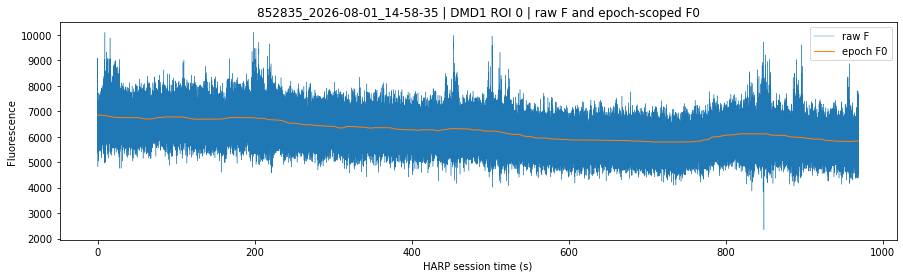

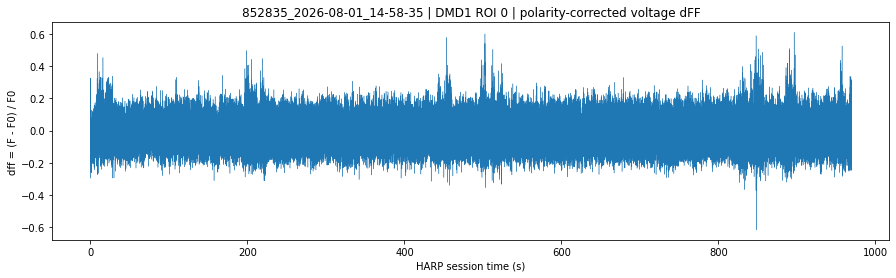

In [12]:
# Pick a voltage session and ROI to inspect.
# This cell uses the saved transform file produced by process_voltage_extraction.

voltage_assets = [a for a in assets if infer_modalities(a)["voltage"]]

if not voltage_assets:
    print("No voltage assets detected in the current session selection.")
else:
    asset = voltage_assets[-1]
    dmd = 1
    roi_index = 0
    trace_signal = "dff_robust_f0"
    trace_mode = resolve_voltage_trace_mode(asset)

    session_trace_h5 = asset.derived_subdir("voltage", create=False) / f"voltage_session_traces_{trace_signal}_{trace_mode}.h5"
    print("Inspecting:", session_trace_h5)

    if not session_trace_h5.exists():
        print("Session trace H5 not found. Run voltage extraction first, or use the next cell to compute one ROI on the fly.")
    else:
        roi = load_voltage_roi_transform_h5(session_trace_h5, dmd=dmd, roi_index=roi_index)
        t = roi["timebase_sec"]
        sample_epoch = roi.get("sample_epoch")
        raw_f = roi["raw_f"]
        f0 = roi["f0"]
        dff = roi["dff"]
        transform_meta = roi.get("metadata", {})
        dff_label = transform_meta.get("transform", "dFF")
        if transform_meta:
            print("Signal transform metadata:")
            display(pd.Series(transform_meta))

        recon_meta = roi.get("reconstruction_metadata", {})
        if recon_meta:
            print("Reconstruction metadata:")
            display(pd.Series(recon_meta))

        fig, ax = plt.subplots(figsize=(15, 4))
        plot_epoch_segmented(ax, t, raw_f, sample_epoch=sample_epoch, lw=0.4, label="raw F")
        plot_epoch_segmented(ax, t, f0, sample_epoch=sample_epoch, lw=1.0, label="epoch F0")
        ax.set_xlabel("HARP session time (s)")
        ax.set_ylabel("Fluorescence")
        ax.set_title(f"{asset.session_id} | DMD{dmd} ROI {roi_index} | raw F and epoch-scoped F0")
        ax.legend()
        plt.show()

        fig, ax = plt.subplots(figsize=(15, 4))
        plot_epoch_segmented(ax, t, dff, sample_epoch=sample_epoch, lw=0.4)
        ax.set_xlabel("HARP session time (s)")
        ax.set_ylabel(dff_label)
        ax.set_title(f"{asset.session_id} | DMD{dmd} ROI {roi_index} | polarity-corrected voltage dFF")
        plt.show()


## 9. Compute one voltage ROI transform on the fly

This is useful before committing to batch F0 settings. It reconstructs the full ROI trace from the session asset, preserves the behavior-derived HARP gaps, estimates F0 independently within every imaging epoch, and returns `raw_f`, `f0`, `dff`, and `sample_epoch` for visualization.


Signal transform metadata:


trace_signal                                                                   dff_robust_f0
trace_signal_requested                                                         dff_robust_f0
output_signal                                                                            dff
chunked_transform                                                                       True
f0_scope                                                                               epoch
indicator                                                                              asap8
dff_polarity_requested                                                                  auto
dff_polarity_source                                                                indicator
fluorescence_response_to_depolarization                depolarization_increases_fluorescence
dff_sign                                                                                   1
transform                                                             

Reconstruction metadata:


epoch_aware                                                                            True
n_epochs                                                                                  2
trial_epoch_assignment_method                                                      provided
scale_each_epoch                                                                      never
scale_tolerance_sec                                                                    0.05
sample_rate_hz_nominal                                                         10686.666992
samples_per_epoch                                             {'1': 3809413, '2': 15168099}
effective_sample_rate_hz_by_epoch            {'1': 10686.6669921875, '2': 10686.6669921875}
nominal_acquired_duration_sec_by_epoch    {'1': 356.4640877071285, '2': 1419.3479605089833}
duration_error_sec_by_epoch               {'1': 8.770744142339026e-05, '2': 5.6508552006...
scaled_by_epoch                                                    {'1': False, 

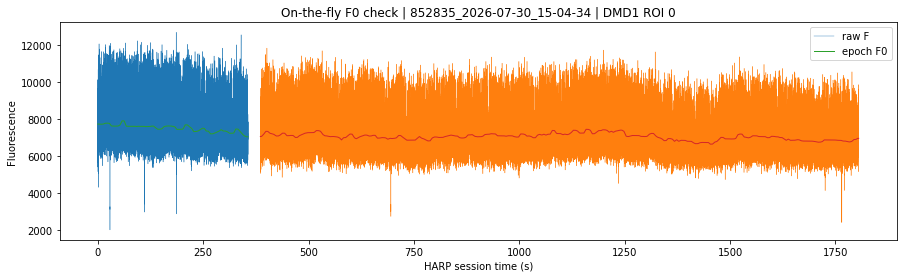

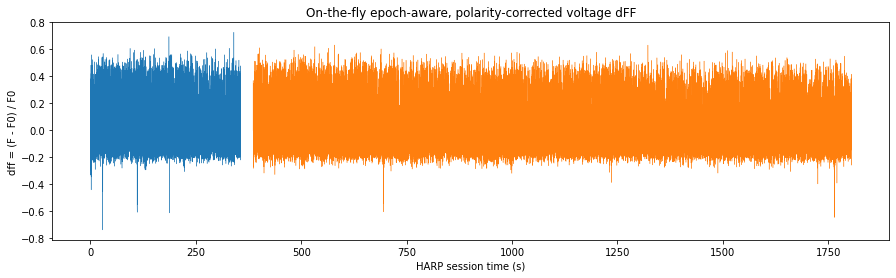

In [13]:
# Compute one ROI transform without running full event extraction.

if not voltage_assets:
    print("No voltage assets detected in the current session selection.")
else:
    asset = voltage_assets[-2]
    dmd = 1
    roi_index = 0

    roi = compute_voltage_roi_transform_from_asset(
        asset,
        dmd=dmd,
        roi_index=roi_index,
        sample_rate_hz=VOLTAGE_SAMPLE_RATE_HZ,
        default_sample_rate_hz=VOLTAGE_DEFAULT_SAMPLE_RATE_HZ,
        trace_mode=resolve_voltage_trace_mode(asset),
        timebase_strategy=VOLTAGE_TIMEBASE_STRATEGY,
        max_timebase_error_sec=VOLTAGE_MAX_TIMEBASE_ERROR_SEC,
        f0_method="robust",       # "static" or "robust"
        f0_scope="epoch",
        f0_percentile=50.0,
        robust_f0_bin_sec=5.0,
        robust_f0_smooth_sec=15.0,
        strict_epoch_match=STRICT_EPOCH_MATCH,
    )

    t = roi["timebase_sec"]
    sample_epoch = roi.get("sample_epoch")
    raw_f = roi["raw_f"]
    f0 = roi["f0"]
    dff = roi["dff"]
    transform_meta = roi.get("metadata", {})
    dff_label = transform_meta.get("transform", "dFF")
    if transform_meta:
        print("Signal transform metadata:")
        display(pd.Series(transform_meta))

    recon_meta = roi.get("reconstruction_metadata", {})
    if recon_meta:
        print("Reconstruction metadata:")
        display(pd.Series(recon_meta))

    fig, ax = plt.subplots(figsize=(15, 4))
    plot_epoch_segmented(ax, t, raw_f, sample_epoch=sample_epoch, lw=0.4, label="raw F")
    plot_epoch_segmented(ax, t, f0, sample_epoch=sample_epoch, lw=1.0, label="epoch F0")
    ax.set_xlabel("HARP session time (s)")
    ax.set_ylabel("Fluorescence")
    ax.set_title(f"On-the-fly F0 check | {asset.session_id} | DMD{dmd} ROI {roi_index}")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(15, 4))
    plot_epoch_segmented(ax, t, dff, sample_epoch=sample_epoch, lw=0.4)
    ax.set_xlabel("HARP session time (s)")
    ax.set_ylabel(dff_label)
    ax.set_title("On-the-fly epoch-aware, polarity-corrected voltage dFF")
    plt.show()


## 10. Expected output folders and reprocessing order

For a fully processed session, outputs should look like:

```text
analysis/qc/behavior/
analysis/qc/slap2/              # glutamate synapse QC
analysis/qc/glutamate/
analysis/qc/calcium/
analysis/qc/voltage/
analysis/derived/glutamate/
analysis/derived/calcium/
analysis/derived/voltage/
```

For multi-epoch voltage sessions, reprocess in this order:

1. Run behavior QC to regenerate `qc/behavior/imaging_epochs.csv`.
2. Run the patched MATLAB `extractDendrites.m` with `outputMode='trial'` or `'both'`.
3. Run voltage QC; the epoch-integrity check must pass.
4. Regenerate dFF/event-aligned means and sequences with this notebook.

Key full-session voltage outputs are:

```text
analysis/derived/voltage/voltage_session_traces_dff_static_f0_trial.h5
analysis/derived/voltage/voltage_session_traces_dff_robust_f0_trial.h5
```

Each contains `raw_f`, epoch-scoped `f0`, polarity-corrected `dff`, the HARP `timebase_sec`, and `sample_epoch`. Event windows that touch an imaging restart are excluded rather than interpolated across the gap.
